# Analytical Power Analysis

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Computing model degrees of freedom

The degrees of freedom are critical for the analytical approach because power is computed from the central and non-central χ² distributions, both parameterized by df.

In [ ]:

# Compute df directly with semPower (no data needed)
df_model <- semPower::semPower.getDf(analyzemodel)

cat("Model degrees of freedom (via semPower):", df_model, "\n")


Model degrees of freedom (via semPower): 249 

## A priori power analysis: Determine N

### Model-free approach (RMSEA-based)

This chunk uses `semPower::semPower.aPriori()` to compute the minimum sample size required for an a priori power analysis based on RMSEA, given the target ($\alpha$), desired power, and model degrees of freedom ([Moshagen & Bader, 2024](#ref-moshagen2024)).

The output returns the required number of observations and the associated quantities reported by `semPower`, such as $F_0$, RMSEA, Mc, the critical chi-square value, and the noncentrality parameter.


 semPower: A priori power analysis
                                   
 F0                        0.622500
 RMSEA                     0.050000
 Mc                        0.732531
 GFI                       0.950683
 AGFI                      0.940582
                                   
 df                        249     
 Required Num Observations 99      
                                   
 Critical Chi-Square       286.8077
 NCP                       61.00500
 Alpha                     0.050000
 Beta                      0.199217
 Power (1 - Beta)          0.800783
 Implied Alpha/Beta Ratio  0.250983

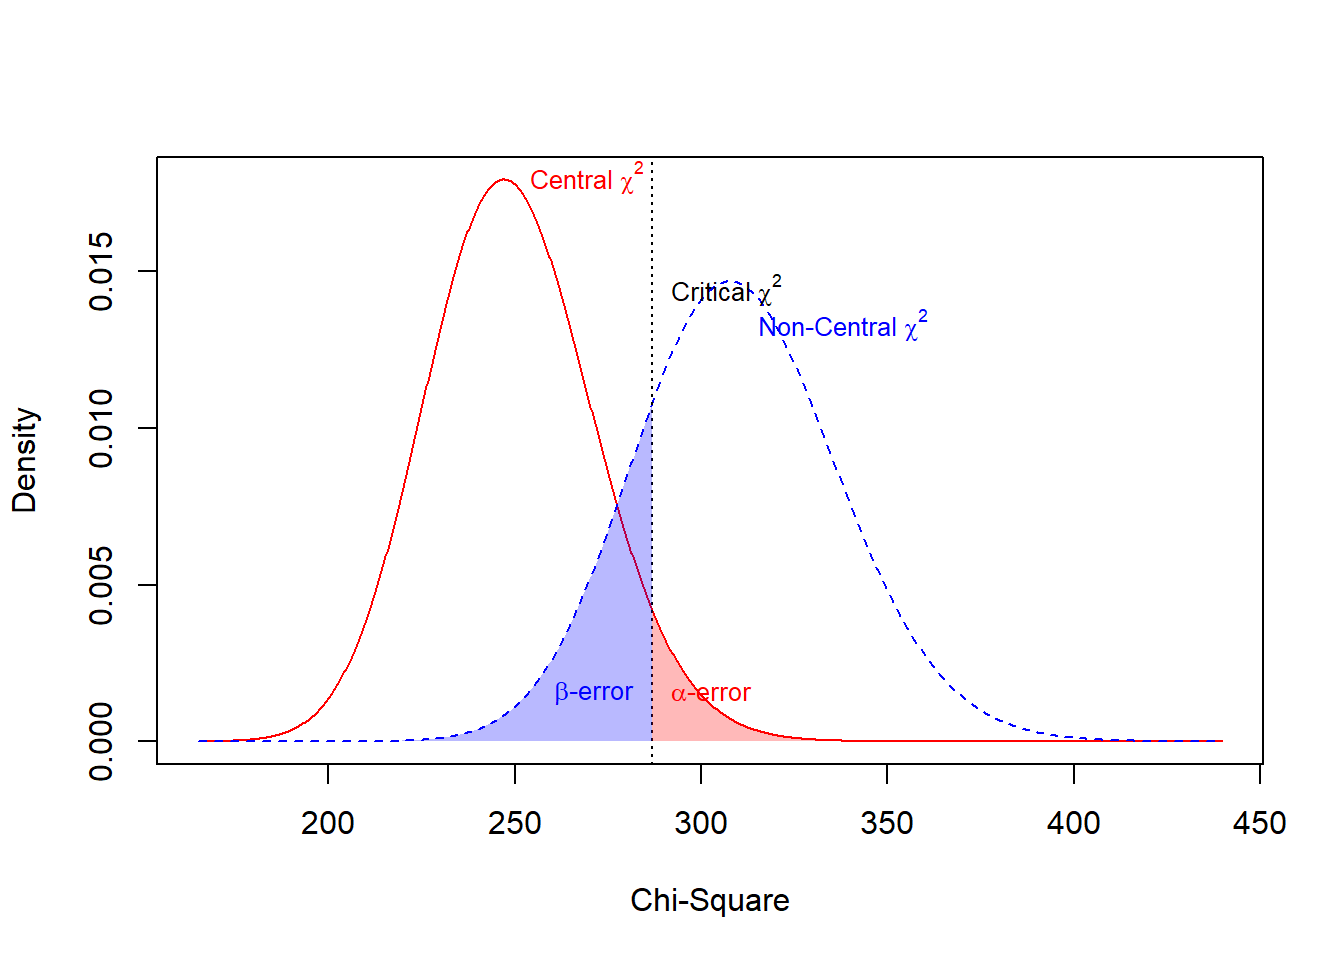

In [ ]:
#! fig-cap: "A priori power analysis for exact fit with RMSEA-based effect size"

# Analytical a priori power analysis for the global chi-square test.
# The goal is to determine the minimum N required to detect
# a population misfit corresponding to RMSEA = 0.05.

ap_rmsea <- semPower::semPower.aPriori(
  effect         = 0.05,      # RMSEA under H1
  effect.measure = "RMSEA",   # effect is expressed as RMSEA
  alpha          = ALPHA,     # Type I error rate
  power          = POWER,     # desired statistical power = 1 - beta
  df             = df_model,  # model degrees of freedom
  p              = P          # only relevant for indices such as GFI/AGFI
)

# Shows effect size, df, required N, critical chi-square,
# noncentrality parameter, and implied alpha/beta results.
summary(ap_rmsea)


### Model-based approach (with lavaan syntax)

This chunk runs an **a priori analytical power analysis** with `semPower.powerLav()`. The function uses the population model (`modelPop`) and the null analysis model (`modelH0`) to determine the minimum sample size required to detect their discrepancy with the target alpha and power ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

Because no `modelH1` is specified, the comparison is made against the **saturated model**, so the test targets global model misfit ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

In [ ]:

# A priori power analysis:
# computes the minimum N needed to detect the discrepancy
# between the population model and the null analysis model.

ap_popmodel <- semPower.powerLav(
  type = "a-priori",       # sample size planning
  alpha = ALPHA,           # Type I error rate
  power = POWER,           # target power
  modelPop = popmodel,     # population-generating model
  modelH0 = analyzemodel,  # null/analysis model
  p = P                    # only relevant for indices such as GFI/AGFI
)

# Shows effect size, df, required N, critical chi-square,
# noncentrality parameter, and implied alpha/beta results.
summary(ap_popmodel)



 semPower: A priori power analysis
                                   
 F0                        0.303870
 RMSEA                     0.034934
 SRMR                      0.175600
 Mc                        0.859044
 GFI                       0.975303
 AGFI                      0.970244
 CFI                       0.977582
                                   
 df                        249     
 Required Num Observations 202     
                                   
 Critical Chi-Square       286.8077
 NCP                       61.07791
 Alpha                     0.050000
 Beta                      0.198481
 Power (1 - Beta)          0.801519
 Implied Alpha/Beta Ratio  0.251914

## Power curves

### Model-free approach

This chunk generates a model-free power curve showing how statistical power changes as a function of sample size $N$ for a fixed effect defined as $\mathrm{RMSEA} = 0.05$, given the chosen significance level $\alpha$ and the model degrees of freedom $df$ ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

In `semPower`, this is an analytical power plot for a noncentrality-based effect measure, so the curve summarizes the expected power across a range of sample sizes while holding the effect size and test conditions constant ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

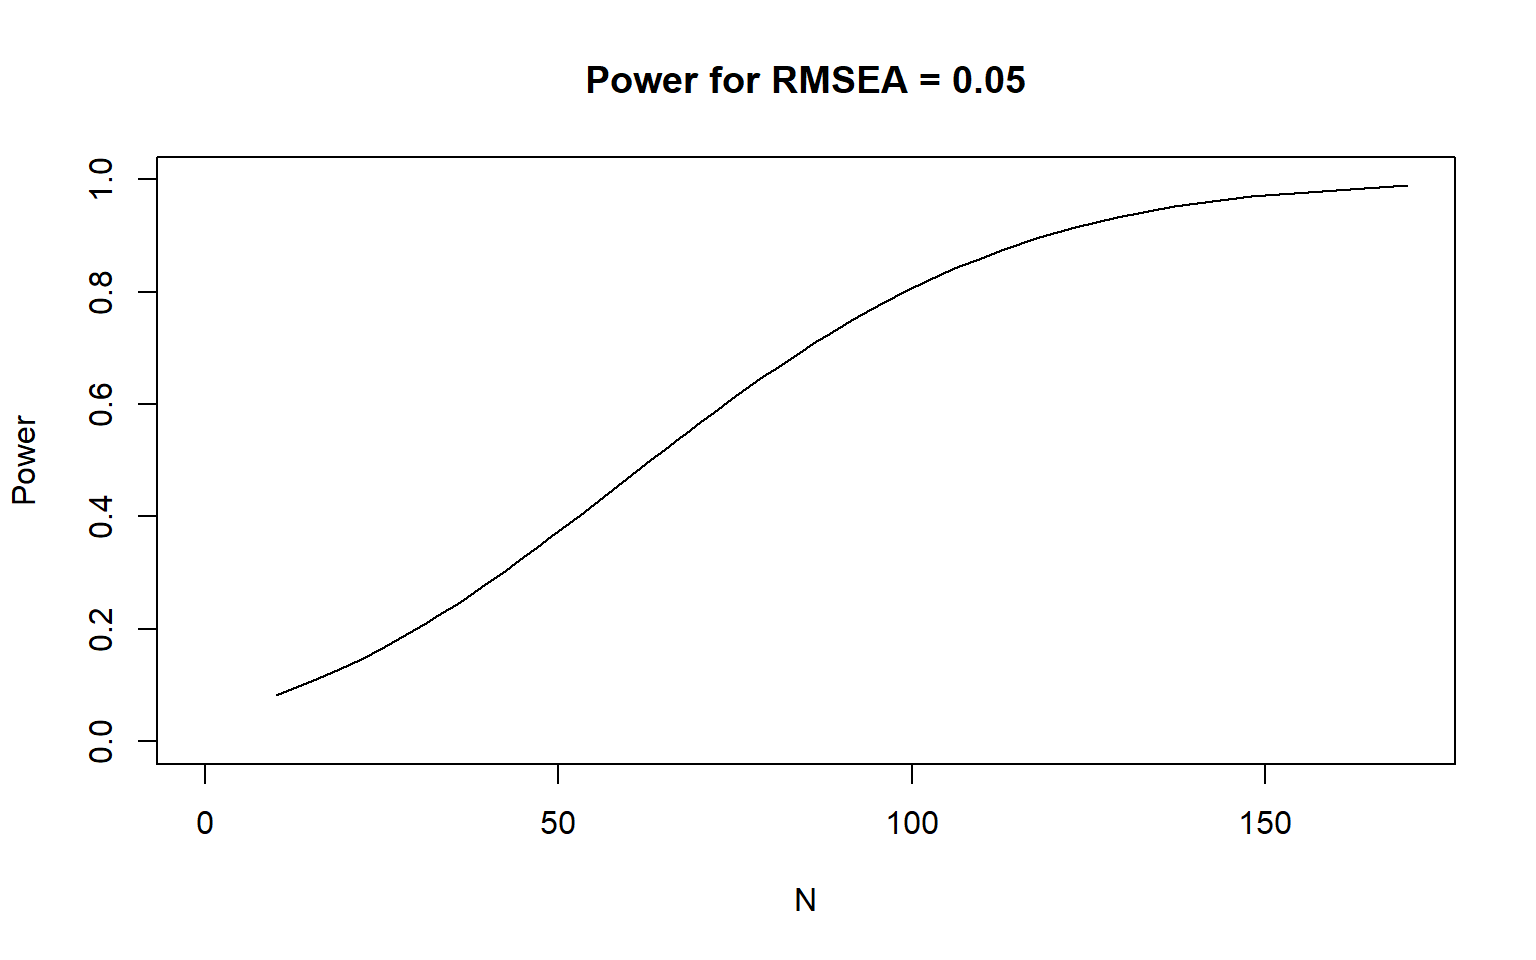

In [ ]:

# Plots statistical power against sample size N.
semPower::semPower.powerPlot.byN(
  effect         = 0.05,      # effect = 0.05 sets the target misfit in RMSEA units.
  effect.measure = "RMSEA",
  alpha          = ALPHA,     # alpha = ALPHA sets the Type I error rate.
  df             = df_model,  # df = df_model sets the model degrees of freedom.
  power.min      = 0.05,
  power.max      = 0.99       # power.min and power.max define the y-axis range of curve.
)


### Model-based approach

This chunk produces a power curve for the model-based analysis stored in `ap_popmodel`, displaying how statistical power changes as a function of sample size $N$ for the effect defined in that object ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)). In `semPower`, `semPower.powerPlot()` is used to visualize the power trajectory implied by a previously estimated power-analysis object, which is useful for identifying the sample-size region in which power becomes adequate ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

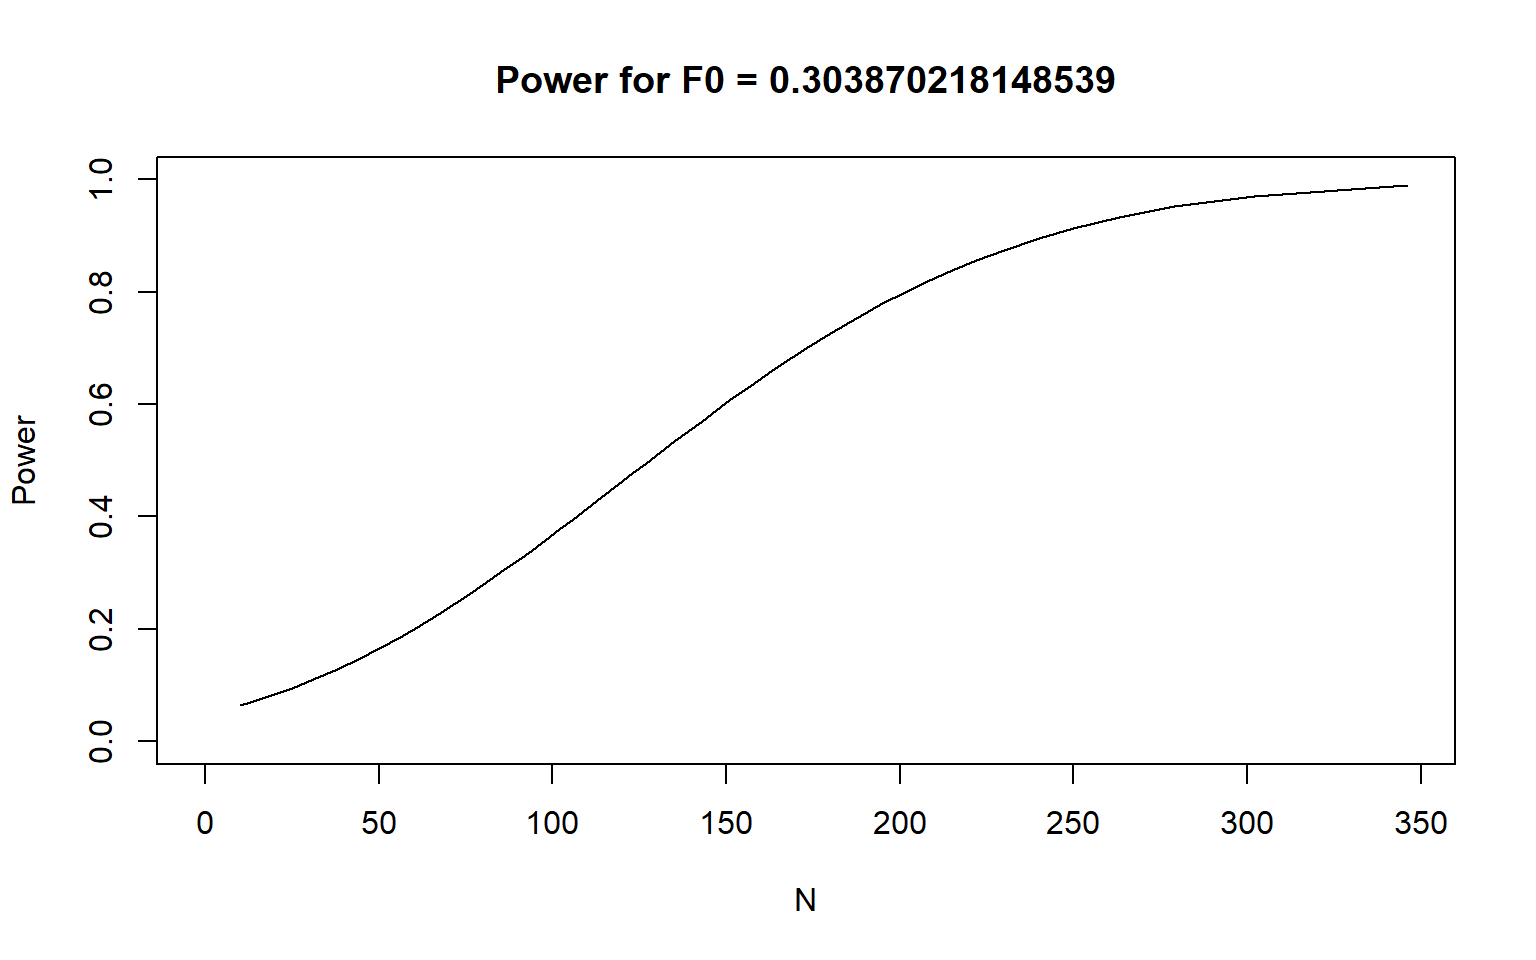

In [ ]:

# Plots the power curve based on the previously computed object `ap_popmodel`.
# x-axis: sample size (N).
# y-axis: statistical power.

semPower.powerPlot(ap_popmodel)


## Summary table

In [ ]:

# Helper to safely extract a single numeric value from each result object
safe_num <- function(x) if (length(x) == 0 || is.null(x)) NA else as.numeric(x)[1]

analytical_summary <- data.frame(
    Method = c(
        "Model-free a priori (RMSEA = .05)",
        "Model-based a priori (Population Model)"
    ),
    `N Required` = c(
        safe_num(ap_rmsea$requiredN),
        safe_num(ap_popmodel$requiredN)
    ),
    `Power` = c(
        round(safe_num(ap_rmsea$impliedPower), 4),
        round(safe_num(ap_popmodel$impliedPower), 4)
    ),
    `Implied RMSEA` = c(
        round(safe_num(ap_rmsea$rmsea), 4),
        round(safe_num(ap_popmodel$rmsea), 4)
    ),
    df = rep(safe_num(df_model), 2),
    check.names = FALSE
)

# Render the summary table with simple column alignment for reporting
knitr::kable(analytical_summary, align = "lccccc")


  ---------------------------------------------------------------------------
  Method                              N Required  Power   Implied RMSEA  df
  ----------------------------------- ---------- -------- ------------- -----
  Model-free a priori (RMSEA = .05)       99      0.8008     0.0500      249

  Model-based a priori (Population       202      0.8015     0.0349      249
  Model)                                                                
  ---------------------------------------------------------------------------


Jobst, L. J., Bader, M., & Moshagen, M. (2023). A tutorial on assessing statistical power and determining sample size for structural equation models. *Psychological Methods*, *28*(1), 207–221. <https://doi.org/10.1037/met0000423>

Moshagen, M., & Bader, M. (2024). <span class="nocase">semPower</span>: General power analysis for structural equation models. *Behavior Research Methods*, *56*(4), 2901–2922. <https://doi.org/10.3758/s13428-023-02254-7>